# Part 2 & 3: ESRI LULC Map & NDVI Calculation
## AOI: Spain (~50 km²) | Landsat 8 Scene

**Task 2:** Download ESRI 10m LULC, display with legend, clip to Landsat extent  
**Task 3:** Calculate NDVI from Landsat bands, display with legend

## 1. Install Dependencies

In [2]:
! pip install rasterio matplotlib numpy pystac-client planetary-computer rioxarray pyproj shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 149.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 96.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [planetary-computer]ioxarray]


## 2. Setup & Load Landsat Data

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask as rio_mask
from rasterio.windows import from_bounds
from pyproj import Transformer
from shapely.geometry import box
from pathlib import Path
import json
import requests

# Path to extracted Landsat data
EXTRACT_DIR = r"D:\Antigravity\landsat_downloads\extracted"
OUTPUT_DIR = r"D:\Antigravity\landsat_downloads"

# Auto-detect Landsat band files
tif_files = list(Path(EXTRACT_DIR).glob("*.TIF"))
bands = {}
for f in tif_files:
    name = f.name.upper()
    if "SR_B2" in name: bands["blue"] = str(f)
    elif "SR_B3" in name: bands["green"] = str(f)
    elif "SR_B4" in name: bands["red"] = str(f)
    elif "SR_B5" in name: bands["nir"] = str(f)
    elif "QA_PIXEL" in name and "RADSAT" not in name: bands["qa"] = str(f)

print("Detected bands:")
for b, p in bands.items():
    print(f"  {b:6s}: {os.path.basename(p)}")

# Get Landsat image metadata
with rasterio.open(bands["red"]) as src:
    landsat_crs = src.crs
    landsat_bounds = src.bounds
    landsat_transform = src.transform
    landsat_width = src.width
    landsat_height = src.height

print(f"\nLandsat CRS   : {landsat_crs}")
print(f"Landsat Bounds: {landsat_bounds}")
print(f"Landsat Size  : {landsat_width} x {landsat_height} px")

# Convert bounds to EPSG:4326 for ESRI LULC download
transformer = Transformer.from_crs(landsat_crs, "EPSG:4326", always_xy=True)
west, south = transformer.transform(landsat_bounds.left, landsat_bounds.bottom)
east, north = transformer.transform(landsat_bounds.right, landsat_bounds.top)
landsat_bbox_4326 = [west, south, east, north]
print(f"Landsat BBox (4326): {landsat_bbox_4326}")

Detected bands:


KeyError: 'red'

---
# TASK 2: ESRI 10m Land Use Land Cover Map

Download from Microsoft Planetary Computer (hosts ESRI LULC as COGs on Azure).

## 3. Download ESRI LULC via Planetary Computer STAC

In [3]:
import pystac_client
import planetary_computer

# Connect to Planetary Computer STAC
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Search for ESRI 10m LULC (9-class annual series)
search = catalog.search(
    collections=["io-lulc-annual-v02"],
    bbox=landsat_bbox_4326,
    datetime="2023-01-01/2024-12-31",
)

items = list(search.items())
print(f"ESRI LULC items found: {len(items)}")

if not items:
    print("Trying alternative collection 'io-lulc'...")
    search = catalog.search(
        collections=["io-lulc"],
        bbox=landsat_bbox_4326,
        datetime="2023-01-01/2024-12-31",
    )
    items = list(search.items())
    print(f"Items found: {len(items)}")

for i, item in enumerate(items):
    print(f"\n  [{i+1}] {item.id}")
    print(f"      Date  : {item.properties.get('datetime')}")
    print(f"      Assets: {list(item.assets.keys())}")

ESRI LULC items found: 4

  [1] 30T-2023
      Date  : None
      Assets: ['data', 'tilejson', 'rendered_preview']

  [2] 30S-2023
      Date  : None
      Assets: ['data', 'tilejson', 'rendered_preview']

  [3] 30T-2022
      Date  : None
      Assets: ['data', 'tilejson', 'rendered_preview']

  [4] 30S-2022
      Date  : None
      Assets: ['data', 'tilejson', 'rendered_preview']


In [4]:
# Select the most recent LULC item
lulc_item = items[0]
print(f"Selected: {lulc_item.id}")

# Get the data asset URL (COG on Azure)
data_asset = lulc_item.assets.get("data") or list(lulc_item.assets.values())[0]
lulc_url = data_asset.href
print(f"COG URL: {lulc_url[:100]}...")

# Read LULC data for Landsat extent using rasterio windowed read
lulc_output = os.path.join(OUTPUT_DIR, "esri_lulc_10m.tif")

print("\nReading ESRI LULC for Landsat extent...")
with rasterio.open(lulc_url) as src:
    lulc_crs = src.crs
    print(f"  LULC CRS: {lulc_crs}")
    print(f"  LULC resolution: {src.res}")
    
    # Transform Landsat bounds to LULC CRS
    t = Transformer.from_crs("EPSG:4326", lulc_crs, always_xy=True)
    lulc_west, lulc_south = t.transform(west, south)
    lulc_east, lulc_north = t.transform(east, north)
    
    # Get window for our AOI
    window = from_bounds(lulc_west, lulc_south, lulc_east, lulc_north, src.transform)
    
    # Read the data
    lulc_data = src.read(1, window=window)
    lulc_transform = src.window_transform(window)
    lulc_profile = src.profile.copy()
    lulc_profile.update({
        'height': lulc_data.shape[0],
        'width': lulc_data.shape[1],
        'transform': lulc_transform
    })

# Save to local file
with rasterio.open(lulc_output, 'w', **lulc_profile) as dst:
    dst.write(lulc_data, 1)

print(f"  LULC shape: {lulc_data.shape}")
print(f"  Unique classes: {np.unique(lulc_data)}")
print(f"  Saved to: {lulc_output}")

Selected: 30T-2023
COG URL: https://ai4edataeuwest.blob.core.windows.net/io-lulc/io-annual-lulc-v02/30T_20230101-20240101.tif?st...

Reading ESRI LULC for Landsat extent...
  LULC CRS: EPSG:32630
  LULC resolution: (10.0, 10.0)
  LULC shape: (15536, 23373)
  Unique classes: [ 0  1  2  4  5  7  8  9 10 11]
  Saved to: D:\Antigravity\landsat_downloads\esri_lulc_10m.tif


## 4. Display ESRI LULC Map with Legend

Display resolution: (15536, 23373) → (1413, 2125) (1:11 subsample)


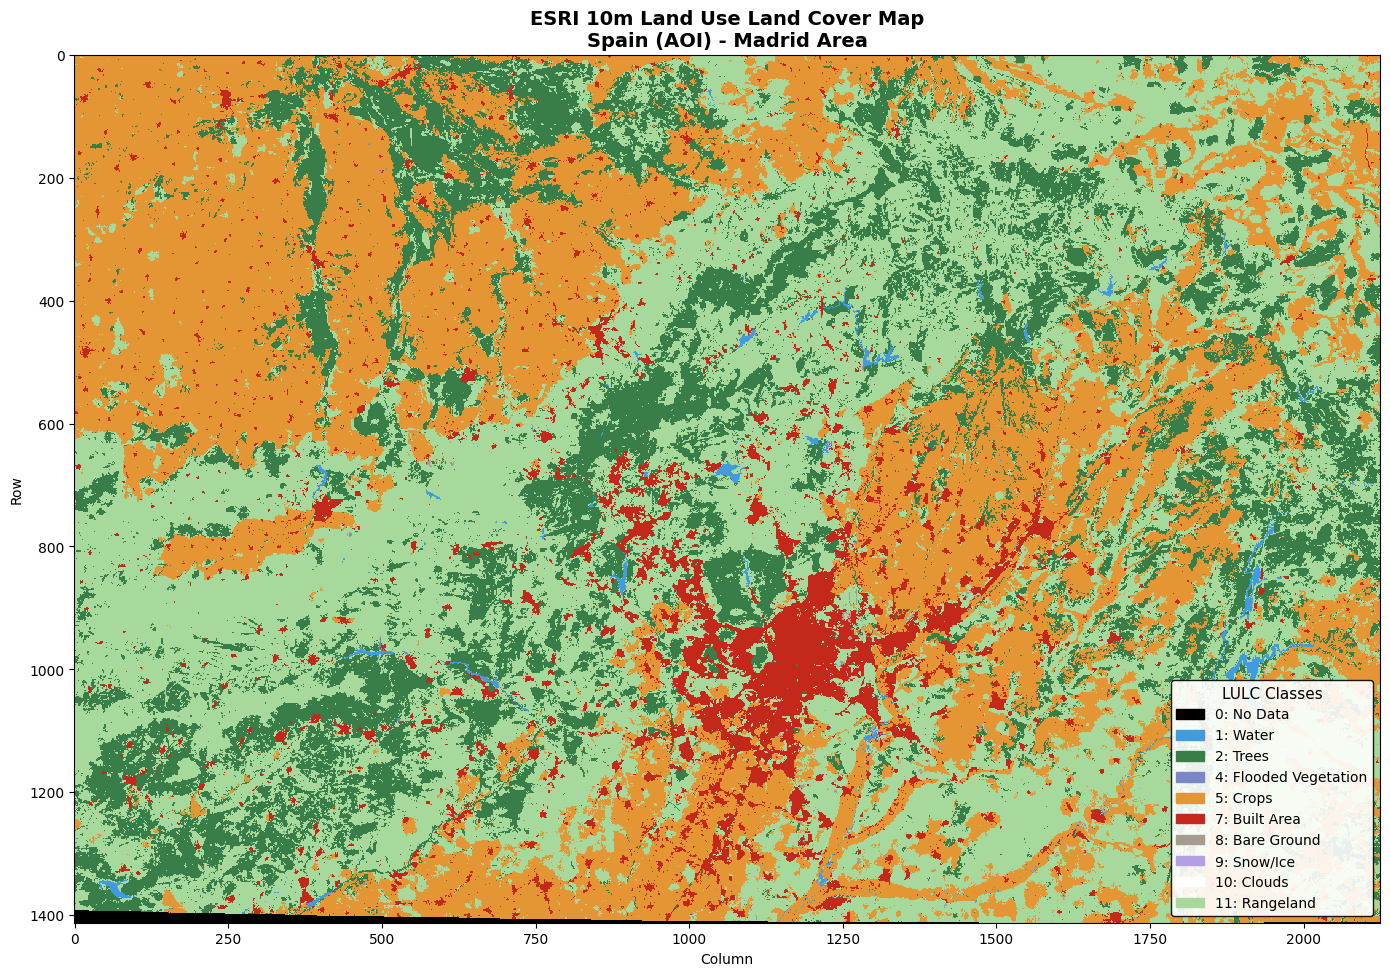


Class Distribution:
   0 - No Data               :  1,446,448 px (0.40%)
   1 - Water                 :  1,668,995 px (0.46%)
   2 - Trees                 : 70,903,521 px (19.53%)
   4 - Flooded Vegetation    :      6,432 px (0.00%)
   5 - Crops                 : 119,187,763 px (32.82%)
   7 - Built Area            : 20,183,825 px (5.56%)
   8 - Bare Ground           :    411,986 px (0.11%)
   9 - Snow/Ice              :        697 px (0.00%)
  10 - Clouds                :        228 px (0.00%)
  11 - Rangeland             : 149,313,033 px (41.12%)


In [5]:
# ESRI 10m LULC class definitions (9-class)
LULC_CLASSES = {
    0: {"name": "No Data",             "color": "#000000"},
    1: {"name": "Water",               "color": "#419BDF"},
    2: {"name": "Trees",               "color": "#397D49"},
    4: {"name": "Flooded Vegetation",  "color": "#7A87C6"},
    5: {"name": "Crops",               "color": "#E49635"},
    7: {"name": "Built Area",          "color": "#C4281B"},
    8: {"name": "Bare Ground",         "color": "#A59B8F"},
    9: {"name": "Snow/Ice",            "color": "#B39FE1"},
    10: {"name": "Clouds",             "color": "#FFFFFF"},
    11: {"name": "Rangeland",           "color": "#A8D99C"},
}

# Build colormap
max_val = max(LULC_CLASSES.keys()) + 1
color_list = ["#000000"] * max_val
for val, info in LULC_CLASSES.items():
    color_list[val] = info["color"]

cmap = mcolors.ListedColormap(color_list)
bounds_cm = list(range(max_val + 1))
norm = mcolors.BoundaryNorm(bounds_cm, cmap.N)

# *** DOWNSAMPLE for display (full-res is 15K x 23K = too slow for matplotlib) ***
scale = max(1, max(lulc_data.shape) // 2000)  # target ~2000px on longest side
lulc_display = lulc_data[::scale, ::scale]
print(f"Display resolution: {lulc_data.shape} → {lulc_display.shape} (1:{scale} subsample)")

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(lulc_display, cmap=cmap, norm=norm, interpolation='nearest')
ax.set_title('ESRI 10m Land Use Land Cover Map\nSpain (AOI) - Madrid Area',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Row')

# Legend
present_classes = np.unique(lulc_data)
legend_patches = []
for val in present_classes:
    if val in LULC_CLASSES:
        info = LULC_CLASSES[val]
        legend_patches.append(
            mpatches.Patch(color=info["color"], label=f"{val}: {info['name']}")
        )

ax.legend(handles=legend_patches, loc='lower right', fontsize=10,
          title='LULC Classes', title_fontsize=11,
          framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'esri_lulc_map.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print class distribution
print("\nClass Distribution:")
total_px = lulc_data.size
for val in present_classes:
    count = np.sum(lulc_data == val)
    pct = count / total_px * 100
    name = LULC_CLASSES.get(val, {}).get('name', 'Unknown')
    print(f"  {val:2d} - {name:22s}: {count:>10,} px ({pct:.2f}%)")

## 5. Clip ESRI LULC to Landsat Image Extent

In [6]:
# Reproject LULC to match Landsat CRS and clip to exact Landsat extent
clipped_output = os.path.join(OUTPUT_DIR, "esri_lulc_clipped.tif")

with rasterio.open(lulc_output) as src:
    # Calculate transform for reprojection to Landsat CRS
    dst_transform, dst_width, dst_height = calculate_default_transform(
        src.crs, landsat_crs,
        src.width, src.height,
        *src.bounds,
        resolution=10  # Keep 10m resolution
    )
    
    dst_profile = src.profile.copy()
    dst_profile.update({
        'crs': landsat_crs,
        'transform': dst_transform,
        'width': dst_width,
        'height': dst_height,
    })
    
    # Reproject
    with rasterio.open(clipped_output, 'w', **dst_profile) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=landsat_crs,
            resampling=Resampling.nearest  # nearest for categorical data
        )

# Read clipped LULC
with rasterio.open(clipped_output) as src:
    lulc_clipped = src.read(1)
    clipped_bounds = src.bounds

print(f"Clipped LULC shape: {lulc_clipped.shape}")
print(f"Clipped CRS: {landsat_crs}")
print(f"Clipped bounds: {clipped_bounds}")
print(f"Saved: {clipped_output}")

Clipped LULC shape: (15536, 23373)
Clipped CRS: EPSG:32630
Clipped bounds: BoundingBox(left=312585.0, bottom=4427755.0, right=546315.0, top=4583115.0)
Saved: D:\Antigravity\landsat_downloads\esri_lulc_clipped.tif


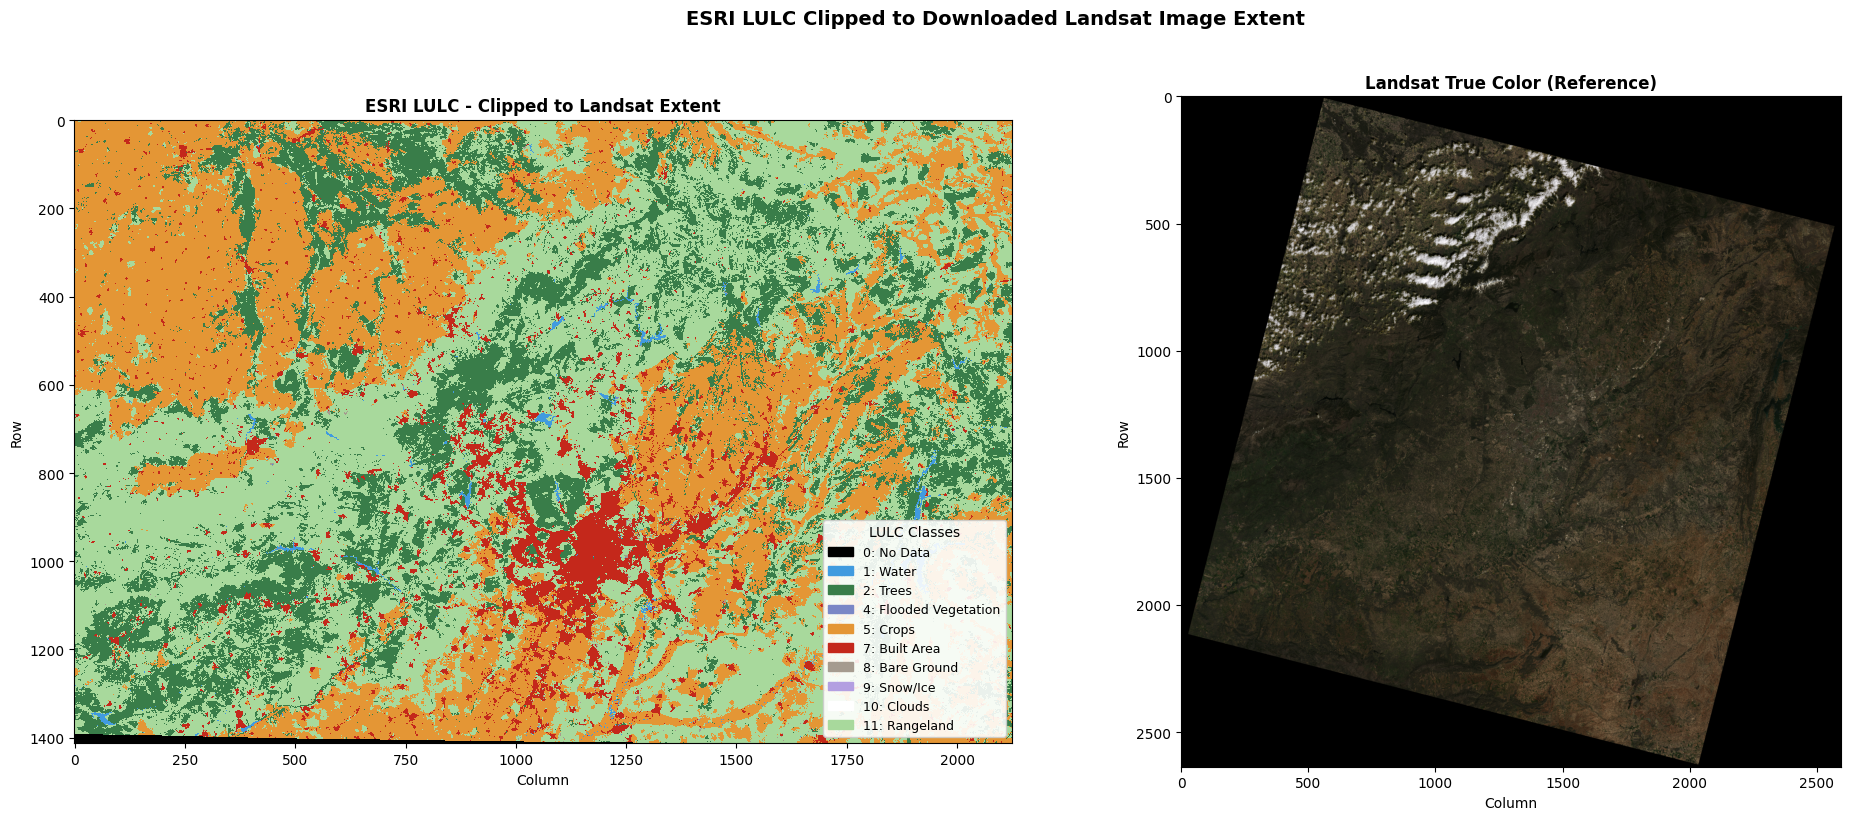

In [7]:
# Display clipped LULC overlaid with Landsat extent comparison
# *** Downsample both for fast display ***
scale_c = max(1, max(lulc_clipped.shape) // 2000)
lulc_clip_disp = lulc_clipped[::scale_c, ::scale_c]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left: Clipped LULC
im1 = axes[0].imshow(lulc_clip_disp, cmap=cmap, norm=norm, interpolation='nearest')
axes[0].set_title('ESRI LULC - Clipped to Landsat Extent',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Column'); axes[0].set_ylabel('Row')

present = np.unique(lulc_clipped)
patches = [mpatches.Patch(color=LULC_CLASSES[v]["color"],
           label=f"{v}: {LULC_CLASSES[v]['name']}")
           for v in present if v in LULC_CLASSES]
axes[0].legend(handles=patches, loc='lower right', fontsize=9,
               title='LULC Classes', framealpha=0.9)

# Right: Landsat True Color for reference (already ~7800px, downsample too)
def normalize_band(band):
    return np.clip(band * 0.0000275 - 0.2, 0, 1)

with rasterio.open(bands["red"]) as s: red = s.read(1).astype(np.float32)
with rasterio.open(bands["green"]) as s: green = s.read(1).astype(np.float32)
with rasterio.open(bands["blue"]) as s: blue = s.read(1).astype(np.float32)

rgb = np.dstack([normalize_band(red), normalize_band(green), normalize_band(blue)])
rgb = np.clip(np.power(rgb, 1.0/1.4), 0, 1)

scale_r = max(1, max(rgb.shape[:2]) // 2000)
rgb_disp = rgb[::scale_r, ::scale_r]

axes[1].imshow(rgb_disp)
axes[1].set_title('Landsat True Color (Reference)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Column'); axes[1].set_ylabel('Row')

plt.suptitle('ESRI LULC Clipped to Downloaded Landsat Image Extent',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lulc_clipped_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---
# TASK 3: NDVI Calculation

**NDVI = (NIR - Red) / (NIR + Red)**

For Landsat 8 OLI:
- **Band 4** (SR_B4) = Red (0.636–0.673 µm)
- **Band 5** (SR_B5) = NIR (0.851–0.879 µm)

## 6. Calculate NDVI

In [8]:
# Read Band 4 (Red) and Band 5 (NIR)
with rasterio.open(bands["red"]) as src:
    red_raw = src.read(1).astype(np.float32)
    ndvi_profile = src.profile.copy()
    ndvi_bounds = src.bounds
    ndvi_crs = src.crs

with rasterio.open(bands["nir"]) as src:
    nir_raw = src.read(1).astype(np.float32)

# Apply Landsat C2 L2 scale factor: SR = DN * 0.0000275 + (-0.2)
red_sr = red_raw * 0.0000275 - 0.2
nir_sr = nir_raw * 0.0000275 - 0.2

# Calculate NDVI
denominator = nir_sr + red_sr
ndvi = np.where(denominator != 0, (nir_sr - red_sr) / denominator, 0)

# Mask out fill/no-data pixels (where raw DN is 0)
nodata_mask = (red_raw == 0) | (nir_raw == 0)
ndvi[nodata_mask] = np.nan

# Clip NDVI to valid range [-1, 1]
ndvi = np.clip(ndvi, -1, 1)

print(f"NDVI computed successfully!")
print(f"  Shape    : {ndvi.shape}")
print(f"  Min      : {np.nanmin(ndvi):.4f}")
print(f"  Max      : {np.nanmax(ndvi):.4f}")
print(f"  Mean     : {np.nanmean(ndvi):.4f}")
print(f"  Std      : {np.nanstd(ndvi):.4f}")
print(f"  No-data  : {np.sum(nodata_mask)} px")

NDVI computed successfully!
  Shape    : (7911, 7791)
  Min      : -1.0000
  Max      : 1.0000
  Mean     : 0.4582
  Std      : 0.1993
  No-data  : 21076070 px


In [9]:
# Save NDVI as GeoTIFF
ndvi_output = os.path.join(OUTPUT_DIR, "ndvi.tif")
ndvi_profile.update(dtype='float32', nodata=np.nan)

with rasterio.open(ndvi_output, 'w', **ndvi_profile) as dst:
    dst.write(ndvi.astype(np.float32), 1)

print(f"NDVI saved to: {ndvi_output}")

NDVI saved to: D:\Antigravity\landsat_downloads\ndvi.tif


## 7. Display NDVI Image with Legend

NDVI display: (7911, 7791) -> (2637, 2597) (1:3)


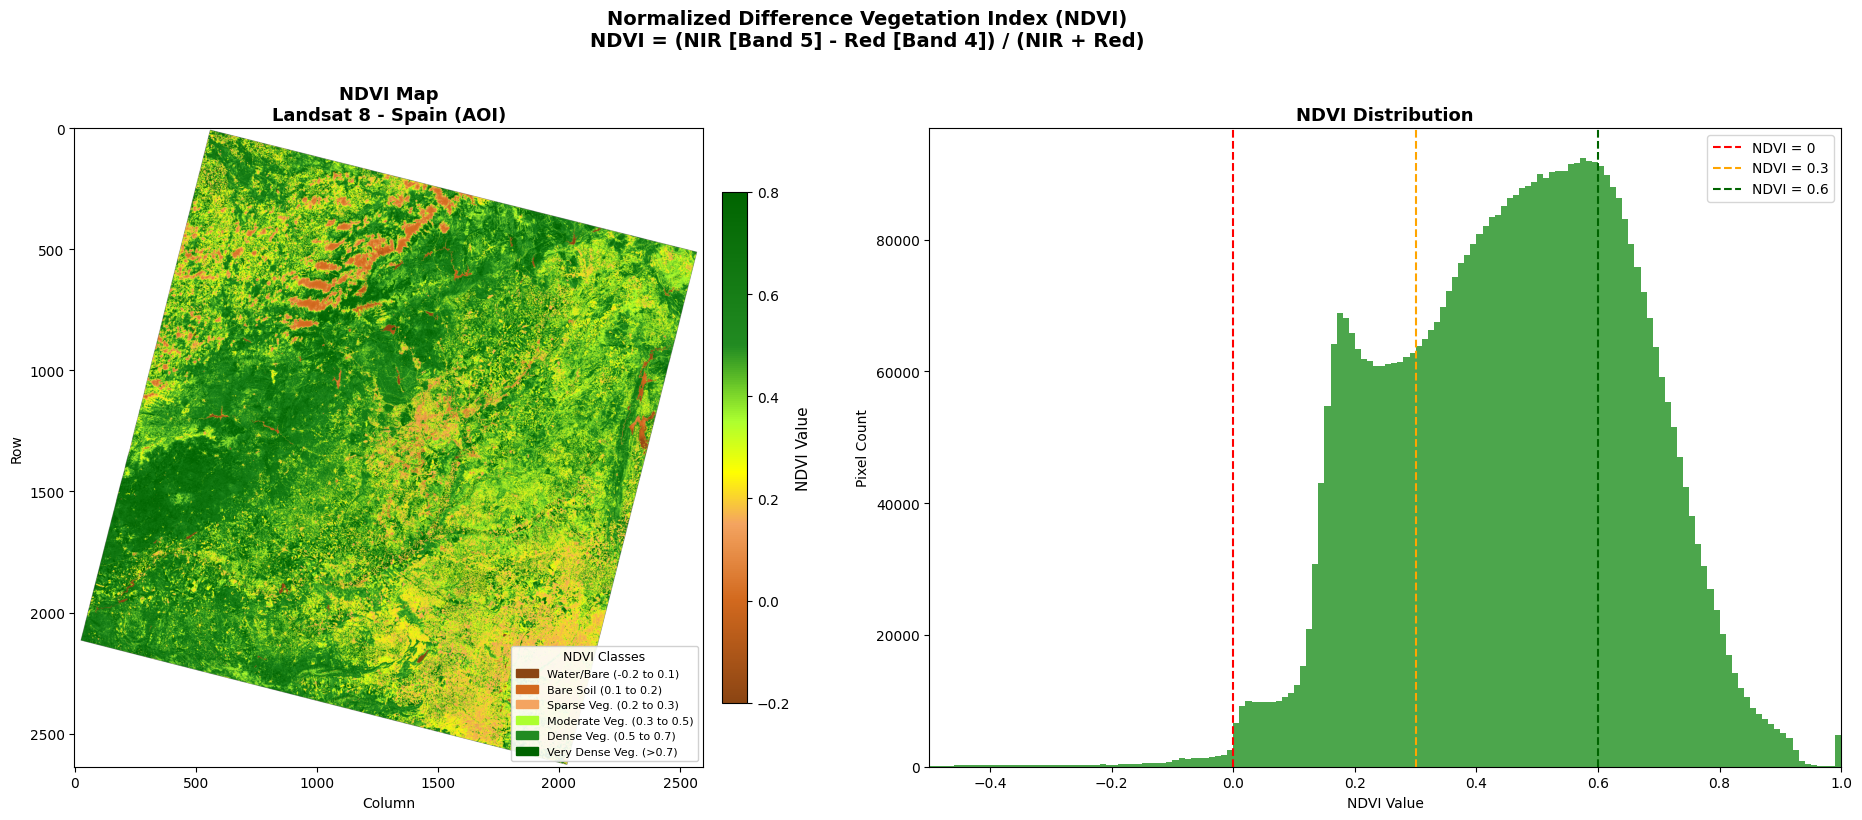


NDVI Statistics:
  Min  : -1.0000
  Max  : 1.0000
  Mean : 0.4582
  Std  : 0.1993

Vegetation Cover:
  Pixels with NDVI > 0.3: 30,919,572 (76.2%)
  Pixels with NDVI > 0.6: 10,841,816 (26.7%)


In [10]:
# Custom NDVI colormap: Brown -> Yellow -> Green
ndvi_colors = [
    (0.0, '#8B4513'),   # Dark brown (water/bare)
    (0.2, '#D2691E'),   # Brown
    (0.35, '#F4A460'),  # Sandy brown
    (0.45, '#FFFF00'),  # Yellow
    (0.55, '#ADFF2F'),  # Green-yellow
    (0.7, '#228B22'),   # Forest green
    (1.0, '#006400'),   # Dark green
]

ndvi_cmap = mcolors.LinearSegmentedColormap.from_list(
    'ndvi', [(pos, color) for pos, color in ndvi_colors], N=256
)

# *** Downsample NDVI for fast display ***
scale_n = max(1, max(ndvi.shape) // 2000)
ndvi_display = ndvi[::scale_n, ::scale_n]
print(f"NDVI display: {ndvi.shape} -> {ndvi_display.shape} (1:{scale_n})")

# Plot NDVI
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left: NDVI map
im1 = axes[0].imshow(ndvi_display, cmap=ndvi_cmap, vmin=-0.2, vmax=0.8)
axes[0].set_title(f'NDVI Map\nLandsat 8 - Spain (AOI)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('Row')
cbar1 = plt.colorbar(im1, ax=axes[0], shrink=0.8, pad=0.02)
cbar1.set_label('NDVI Value', fontsize=11)

# Add NDVI interpretation legend
ndvi_legend = [
    mpatches.Patch(color='#8B4513', label='Water/Bare (-0.2 to 0.1)'),
    mpatches.Patch(color='#D2691E', label='Bare Soil (0.1 to 0.2)'),
    mpatches.Patch(color='#F4A460', label='Sparse Veg. (0.2 to 0.3)'),
    mpatches.Patch(color='#ADFF2F', label='Moderate Veg. (0.3 to 0.5)'),
    mpatches.Patch(color='#228B22', label='Dense Veg. (0.5 to 0.7)'),
    mpatches.Patch(color='#006400', label='Very Dense Veg. (>0.7)'),
]
axes[0].legend(handles=ndvi_legend, loc='lower right', fontsize=8,
               title='NDVI Classes', title_fontsize=9, framealpha=0.9)

# Right: NDVI histogram (use subsample for speed)
ndvi_valid = ndvi[~np.isnan(ndvi)].flatten()
# Subsample histogram data if > 5M points
if len(ndvi_valid) > 5_000_000:
    hist_data = np.random.choice(ndvi_valid, 5_000_000, replace=False)
else:
    hist_data = ndvi_valid

axes[1].hist(hist_data, bins=200, color='green', alpha=0.7, edgecolor='none')
axes[1].axvline(x=0, color='red', linestyle='--', label='NDVI = 0')
axes[1].axvline(x=0.3, color='orange', linestyle='--', label='NDVI = 0.3')
axes[1].axvline(x=0.6, color='darkgreen', linestyle='--', label='NDVI = 0.6')
axes[1].set_title('NDVI Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('NDVI Value')
axes[1].set_ylabel('Pixel Count')
axes[1].legend(fontsize=10)
axes[1].set_xlim(-0.5, 1.0)

plt.suptitle(f'Normalized Difference Vegetation Index (NDVI)\n'
             f'NDVI = (NIR [Band 5] - Red [Band 4]) / (NIR + Red)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ndvi_map.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print(f"\nNDVI Statistics:")
print(f"  Min  : {np.nanmin(ndvi):.4f}")
print(f"  Max  : {np.nanmax(ndvi):.4f}")
print(f"  Mean : {np.nanmean(ndvi):.4f}")
print(f"  Std  : {np.nanstd(ndvi):.4f}")
print(f"\nVegetation Cover:")
veg_px = np.sum(ndvi_valid > 0.3)
print(f"  Pixels with NDVI > 0.3: {veg_px:,} ({veg_px/len(ndvi_valid)*100:.1f}%)")
dense_px = np.sum(ndvi_valid > 0.6)
print(f"  Pixels with NDVI > 0.6: {dense_px:,} ({dense_px/len(ndvi_valid)*100:.1f}%)")

## 8. Summary

In [11]:
print("="*60)
print("TASK 2 & 3 SUMMARY")
print("="*60)
print(f"\n--- Task 2: ESRI LULC ---")
print(f"  Source      : ESRI 10m Annual LULC (via Planetary Computer)")
print(f"  Resolution  : 10 m")
print(f"  LULC file   : {lulc_output}")
print(f"  Clipped file: {clipped_output}")
print(f"  Classes found: {len(present)} unique values")
print(f"\n--- Task 3: NDVI ---")
print(f"  Formula     : (Band 5 [NIR] - Band 4 [Red]) / (Band 5 + Band 4)")
print(f"  NDVI file   : {ndvi_output}")
print(f"  NDVI range  : [{np.nanmin(ndvi):.4f}, {np.nanmax(ndvi):.4f}]")
print(f"  Mean NDVI   : {np.nanmean(ndvi):.4f}")
print(f"\n--- Output Files ---")
for f in Path(OUTPUT_DIR).glob('*'):
    if f.is_file():
        print(f"  {f.name} ({f.stat().st_size/(1024*1024):.1f} MB)")
print("="*60)

TASK 2 & 3 SUMMARY

--- Task 2: ESRI LULC ---
  Source      : ESRI 10m Annual LULC (via Planetary Computer)
  Resolution  : 10 m
  LULC file   : D:\Antigravity\landsat_downloads\esri_lulc_10m.tif
  Clipped file: D:\Antigravity\landsat_downloads\esri_lulc_clipped.tif
  Classes found: 10 unique values

--- Task 3: NDVI ---
  Formula     : (Band 5 [NIR] - Band 4 [Red]) / (Band 5 + Band 4)
  NDVI file   : D:\Antigravity\landsat_downloads\ndvi.tif
  NDVI range  : [-1.0000, 1.0000]
  Mean NDVI   : 0.4582

--- Output Files ---
  esri_lulc_10m.tif (8.4 MB)
  esri_lulc_clipped.tif (8.4 MB)
  esri_lulc_map.png (0.6 MB)
  LC08_L2SP_201032_20260331_20260407_02_T1.tar (955.2 MB)
  lulc_clipped_comparison.png (1.8 MB)
  ndvi.tif (135.8 MB)
  ndvi_map.png (1.7 MB)
  true_color_composite.png (2.2 MB)
